# IEE 575 — Conditioning and Closure Properties

**Goal:** Build the mathematical machinery needed for Gaussian Process regression.

**Structure:**
1. Matrix operations with Gaussians
2. Closure properties
3. Conditioning mechanics
4. Geometric intuition

**Method:**
- Read the setup
- Predict the outcome
- Write/fix the code
- Run and verify
- Explain any mismatches

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

np.random.seed(42)

# Part 1: Matrix Operations with Gaussians

Understanding how matrices transform Gaussian distributions is essential for GP mathematics.

## Exercise 1: Scalar Multiplication

**Setup:** You have $X \sim \mathcal{N}(0, 1)$. You compute $Y = 3X$.

**Question:** What are the mean and variance of $Y$?

**Theory:** If $Y = aX$ where $X \sim \mathcal{N}(\mu, \sigma^2)$, then $Y \sim \mathcal{N}(a\mu, a^2\sigma^2)$.

**Your prediction:**

Mean of Y =

Variance of Y =

---

In [ ]:
# Exercise — Linear Transformations of a Gaussian

# Context:
# A key property of Gaussian distributions is that linear transformations preserve normality.
# If X ~ N(μ, σ^2), then Y = aX ~ N(aμ, a^2 σ^2)

# =====================================================
# Your Task:
# 1. Generate samples from X ~ N(0, 1)
# 2. Choose a scalar a
# 3. Compute Y = a * X
# 4. Compute sample mean and variance of Y
# 5. Compare with theoretical variance
# 6. Plot histograms of X and Y
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# Sample from N(0, 1)
n_samples = 10000
X = ...

# TODO: choose a value for a and compute Y
a = None
Y = None

# TODO: compute and print sample mean and variance of Y
# print(...)

# TODO: compute and print theoretical variance
# print(...)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].hist(X, bins=50, density=True, alpha=0.6, label='X ~ N(0,1)')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Density')
ax[0].legend()

# TODO: plot histogram of Y
# ax[1].hist(...)

plt.tight_layout()
plt.show()

# =====================================================
# Think:
# - What happens to the spread when a increases?
# - Does the distribution remain Gaussian?
# - How does variance scale with a?
# =====================================================

**Explain:** Did your prediction match? Why does the variance scale by $a^2$ and not $a$?

**Your explanation:**

---

## Exercise 2: Affine Transformation

**Setup:** You have $X \sim \mathcal{N}(2, 4)$. You compute $Y = -2X + 5$.

**Question:** What are the mean and variance of $Y$?

**Theory:** If $Y = aX + b$ where $X \sim \mathcal{N}(\mu, \sigma^2)$, then $Y \sim \mathcal{N}(a\mu + b, a^2\sigma^2)$.

Note: Adding a constant shifts the mean but does not affect variance.

**Your prediction:**

Mean of Y =

Variance of Y =

---

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Sample from N(0, 1)
n_samples = 10000
X = ...

# TODO: choose a value for a and compute Y
a = None
b = None

Y = None

# TODO: compute and print sample mean and variance of Y
# print(...)

# TODO: compute and print theoretical variance
# print(...)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].hist(X, bins=50, density=True, alpha=0.6, label='X ~ N(0,1)')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Density')
ax[0].legend()

# TODO: plot histogram of Y
# ax[1].hist(...)

plt.tight_layout()
plt.show()


**Explain:** Why doesn't adding a constant change the variance?

**Your explanation:**

---

## Exercise 3: Matrix-Vector Multiplication

**Setup:** You have $\mathbf{X} = \begin{bmatrix} X_1 \\ X_2 \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}\right)$.

You compute $Y = \begin{bmatrix} 2 & 1 \end{bmatrix} \mathbf{X} = 2X_1 + X_2$.

**Question:** What are the mean and variance of $Y$?

**Theory:** If $Y = \mathbf{w}^T \mathbf{X}$ where $\mathbf{X} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, then:
$$Y \sim \mathcal{N}(\mathbf{w}^T \boldsymbol{\mu}, \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w})$$

**Your prediction:**

Mean of Y =

Variance of Y =

---

Sample mean of Y: 0.176
Sample variance of Y: 5.432
Theoretical mean: 0.000
Theoretical variance: 5.000


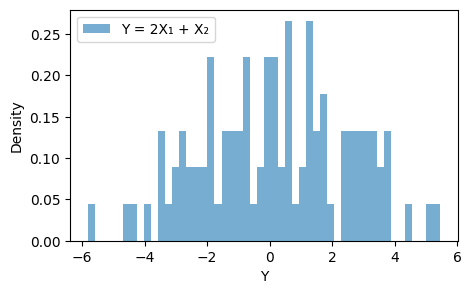

In [13]:

n_samples = 100

# Sample from bivariate N(0, I)
mu = np.array([0, 0])
Sigma = np.array([[1, 0],
                   [0, 1]])

X = np.random.multivariate_normal(mu, Sigma, size=n_samples)

# Transform: Y = 2*X1 + X2
w = np.array([2, 1])

# FILL THIS IN (hint: matrix multiplication or X @ w)
Y = X @ w

# Theoretical values
theoretical_mean = w.T @ mu
theoretical_var = w.T @ Sigma @ w

# Empirical values
print(f"Sample mean of Y: {Y.mean():.3f}")
print(f"Sample variance of Y: {Y.var():.3f}")
print(f"Theoretical mean: {theoretical_mean:.3f}")
print(f"Theoretical variance: {theoretical_var:.3f}")

# Visualize
plt.figure(figsize=(5, 3))
plt.hist(Y, bins=50, density=True, alpha=0.6, label='Y = 2X₁ + X₂')
plt.xlabel('Y')
plt.ylabel('Density')
plt.legend()
plt.show()

**Explain:** Verify your hand calculation of $\mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w}$ matches the code output.

**Your calculation:**

---

## Exercise 4: Correlated Case

**Setup:** Same as Exercise 3, but now:
$$\boldsymbol{\Sigma} = \begin{bmatrix} 1 & 0.7 \\ 0.7 & 1 \end{bmatrix}$$

You still compute $Y = 2X_1 + X_2$.

**Question:** How does correlation between $X_1$ and $X_2$ affect the variance of $Y$?

**Prediction:** Will the variance be larger or smaller than Exercise 3? Why?

**Your prediction:**

Variance will be (larger/smaller) because:

Hand calculation of $\mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w}$:

---

In [14]:
# Sample from correlated bivariate Gaussian
mu = np.array([0, 0])
Sigma = np.array([[1, 0.7],
                   [0.7, 1]])

X = np.random.multivariate_normal(mu, Sigma, size=n_samples)

# Transform
w = np.array([2, 1])
Y = X @ w

# Theoretical values
theoretical_mean = w.T @ mu
theoretical_var = w.T @ Sigma @ w

# Empirical values
print(f"Sample mean of Y: {Y.mean():.3f}")
print(f"Sample variance of Y: {Y.var():.3f}")
print(f"Theoretical variance: {theoretical_var:.3f}")
print(f"\nCompare to Exercise 3 variance: 5.0")
print(f"Difference: {theoretical_var - 5.0:.3f}")

Sample mean of Y: -0.254
Sample variance of Y: 7.718
Theoretical variance: 7.800

Compare to Exercise 3 variance: 5.0
Difference: 2.800


**Explain:** Why did positive correlation increase the variance of $Y = 2X_1 + X_2$?

**Your explanation:**

---

# Part 2: Closure Properties

Gaussians remain Gaussian under linear transformations. This is critical for GP theory.

## Exercise 5: Sum of Independent Gaussians

**Setup:** $X \sim \mathcal{N}(2, 3)$ and $Y \sim \mathcal{N}(-1, 2)$ are independent.

You compute $Z = X + Y$.

**Theory:** If $X$ and $Y$ are independent Gaussians, then:
$$Z = X + Y \sim \mathcal{N}(\mu_X + \mu_Y, \sigma_X^2 + \sigma_Y^2)$$

**Your prediction:**

Mean of Z =

Variance of Z =

Is Z Gaussian?

---

In [15]:
# Sample independent Gaussians
mu_X, sigma2_X = 2, 3
mu_Y, sigma2_Y = -1, 2

X = np.random.randn(n_samples) * np.sqrt(sigma2_X) + mu_X
Y = # FILL THIS IN

# Sum
Z = X + Y

# Theoretical
theoretical_mean = mu_X + mu_Y
theoretical_var = sigma2_X + sigma2_Y

print(f"Sample mean: {Z.mean():.3f}")
print(f"Sample variance: {Z.var():.3f}")
print(f"Theoretical mean: {theoretical_mean}")
print(f"Theoretical variance: {theoretical_var}")

# Visualize
plt.figure(figsize=(5, 3))
plt.hist(Z, bins=50, density=True, alpha=0.6, label='Z = X + Y (empirical)')

# Overlay theoretical Gaussian
z_range = np.linspace(Z.min(), Z.max(), 200)
plt.plot(z_range,
         norm.pdf(z_range, theoretical_mean, np.sqrt(theoretical_var)),
         'r-', linewidth=2, label='Theoretical N(μ, σ²)')

plt.xlabel('Z')
plt.ylabel('Density')
plt.legend()
plt.show()

SyntaxError: invalid syntax (612519476.py, line 6)

**Explain:** Does the histogram match the theoretical curve? What does this tell you?

**Your explanation:**

---

## Exercise 6: Linear Combination with Correlation

**Setup:**
$$\begin{bmatrix} X_1 \\ X_2 \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} 1 \\ -1 \end{bmatrix}, \begin{bmatrix} 2 & 1 \\ 1 & 3 \end{bmatrix}\right)$$

You compute $Z = 3X_1 - 2X_2$.

**Question:** Is $Z$ Gaussian? What are its parameters?

**Theory:** $Z = \mathbf{w}^T \mathbf{X}$ where $\mathbf{w} = [3, -2]^T$.

**Your prediction:**

Is Z Gaussian?

Mean of Z =

Variance of Z = (compute $\mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w}$)

---

In [ ]:
# Sample from bivariate Gaussian
mu = np.array([1, -1])
Sigma = np.array([[2, 1],
                   [1, 3]])

X = np.random.multivariate_normal(mu, Sigma, size=n_samples)

# Linear combination: Z = 3*X1 - 2*X2
w = np.array([3, -2])
Z = # FILL THIS IN

# Theoretical
theoretical_mean = w.T @ mu
theoretical_var = w.T @ Sigma @ w

print(f"Sample mean: {Z.mean():.3f}")
print(f"Sample variance: {Z.var():.3f}")
print(f"Theoretical mean: {theoretical_mean}")
print(f"Theoretical variance: {theoretical_var}")

# Visualize
plt.figure(figsize=(5, 3))
plt.hist(Z, bins=50, density=True, alpha=0.6, label='Z = 3X₁ - 2X₂')

z_range = np.linspace(Z.min(), Z.max(), 200)
plt.plot(z_range,
         norm.pdf(z_range, theoretical_mean, np.sqrt(theoretical_var)),
         'r-', linewidth=2, label='Theoretical Gaussian')

plt.xlabel('Z')
plt.ylabel('Density')
plt.legend()
plt.show()

**Explain:** Why is this important for GPs?

**Your explanation:**

---

# Part 3: Conditioning Mechanics

This is the core operation in GP prediction.

## Conditioning Formulas

Given:
$$\begin{bmatrix} X_1 \\ X_2 \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}, \begin{bmatrix} \Sigma_{11} & \Sigma_{12} \\ \Sigma_{21} & \Sigma_{22} \end{bmatrix}\right)$$

The conditional distribution is:
$$X_2 | X_1 = x_1 \sim \mathcal{N}(\mu_{2|1}, \Sigma_{2|1})$$

where:
$$\mu_{2|1} = \mu_2 + \Sigma_{21} \Sigma_{11}^{-1} (x_1 - \mu_1)$$
$$\Sigma_{2|1} = \Sigma_{22} - \Sigma_{21} \Sigma_{11}^{-1} \Sigma_{12}$$

**Key observations:**
1. The conditional mean shifts based on the observed deviation from expectation
2. The conditional variance is always smaller (uncertainty reduced by observation)
3. The conditional distribution is still Gaussian

## Exercise 7: Bivariate Conditioning

**Setup:**
$$\begin{bmatrix} X_1 \\ X_2 \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 1 & 0.8 \\ 0.8 & 1 \end{bmatrix}\right)$$

**Task:** Compute the conditional distribution of $X_2 | X_1 = 1.5$ by hand, then verify with code.

**Your hand calculation:**

$\mu_{2|1} = $

$\Sigma_{2|1} = $

---

In [ ]:
# Define joint distribution
mu = np.array([0, 0])
Sigma = np.array([[1, 0.8],
                   [0.8, 1]])

# Partition
mu1 = mu[0]
mu2 = mu[1]
Sigma11 = Sigma[0, 0]
Sigma12 = Sigma[0, 1]
Sigma21 = Sigma[1, 0]
Sigma22 = Sigma[1, 1]

# Observed value
x1_obs = 1.5

# Conditional parameters
mu_cond = # FILL THIS IN using the formula
Sigma_cond = # FILL THIS IN using the formula

print(f"Conditional mean: {mu_cond:.3f}")
print(f"Conditional variance: {Sigma_cond:.3f}")
print(f"Conditional std dev: {np.sqrt(Sigma_cond):.3f}")

**Explain:** Does your hand calculation match? Why did observing $X_1 = 1.5$ shift the mean of $X_2$ to a positive value?

**Your explanation:**

---

## Exercise 8: Effect of Correlation

**Setup:** Same as Exercise 7, but vary the correlation.

**Task:** Compute conditional distributions for $\rho \in \{0, 0.5, 0.9, 0.99\}$ when $X_1 = 1.5$.

**Prediction:** How will the conditional mean and variance change as correlation increases?

**Your prediction:**

As ρ increases, conditional mean will:

As ρ increases, conditional variance will:

---

In [ ]:
rho_values = [0, 0.5, 0.9, 0.99]
x1_obs = 1.5

print(f"Conditioning on X1 = {x1_obs}\n")
print(f"{'ρ':<6} {'μ_2|1':<10} {'σ²_2|1':<10}")
print("-" * 30)

for rho in rho_values:
    Sigma = np.array([[1, rho],
                       [rho, 1]])

    # Extract components
    Sigma11 = Sigma[0, 0]
    Sigma12 = Sigma[0, 1]
    Sigma21 = Sigma[1, 0]
    Sigma22 = Sigma[1, 1]

    # Conditional parameters
    mu_cond = # FILL THIS IN
    Sigma_cond = # FILL THIS IN

    print(f"{rho:<6} {mu_cond:<10.3f} {Sigma_cond:<10.3f}")

**Explain:** What happens to uncertainty as correlation approaches 1? Why?

**Your explanation:**

---

## Exercise 9: Multivariate Conditioning

**Setup:**
$$\begin{bmatrix} X_1 \\ X_2 \\ X_3 \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 1 & 0.7 & 0.5 \\ 0.7 & 1 & 0.6 \\ 0.5 & 0.6 & 1 \end{bmatrix}\right)$$

**Task:** Condition on $X_1 = 1.0$ and $X_3 = -0.5$ to find the distribution of $X_2$.

This is the GP prediction setup: predicting one location given observations at others.

**Your prediction:**

Will $\mu_{2|1,3}$ be positive or negative? Why?

Will $\sigma^2_{2|1,3}$ be smaller than the marginal variance of $X_2$?

---

In [ ]:
# Joint distribution
mu = np.array([0, 0, 0])
Sigma = np.array([[1.0, 0.7, 0.5],
                   [0.7, 1.0, 0.6],
                   [0.5, 0.6, 1.0]])

# Observations
x_obs = np.array([1.0, -0.5])  # X1 = 1.0, X3 = -0.5

# Partition: predict X2 (index 1) given X1, X3 (indices 0, 2)
obs_idx = [0, 2]
pred_idx = [1]

mu_obs = mu[obs_idx]
mu_pred = mu[pred_idx]

Sigma_obs_obs = Sigma[np.ix_(obs_idx, obs_idx)]
Sigma_pred_obs = Sigma[np.ix_(pred_idx, obs_idx)]
Sigma_obs_pred = Sigma[np.ix_(obs_idx, pred_idx)]
Sigma_pred_pred = Sigma[np.ix_(pred_idx, pred_idx)]

# Conditioning formulas
mu_cond = # FILL THIS IN
Sigma_cond = # FILL THIS IN

print(f"Conditioning on X1 = {x_obs[0]}, X3 = {x_obs[1]}")
print(f"\nConditional distribution of X2:")
print(f"  Mean: {mu_cond[0]:.3f}")
print(f"  Variance: {Sigma_cond[0,0]:.3f}")
print(f"\nMarginal variance of X2 (no observations): {Sigma[1,1]:.3f}")
print(f"Variance reduction: {Sigma[1,1] - Sigma_cond[0,0]:.3f}")

**Explain:** Why did the mean shift in the direction it did? Why did observing two variables reduce variance more than observing one?

**Your explanation:**

---

# Part 4: Geometric Intuition

Visualizing what conditioning does to a Gaussian distribution.

## Exercise 10: Conditioning as a Slice

**Concept:** Conditioning on $X_1 = x_1$ is like taking a vertical slice through the joint density.

The slice shows the joint density $p(x_1, X_2)$ at that fixed $x_1$.

The conditional density $p(X_2 | X_1 = x_1)$ is this slice, renormalized to integrate to 1.

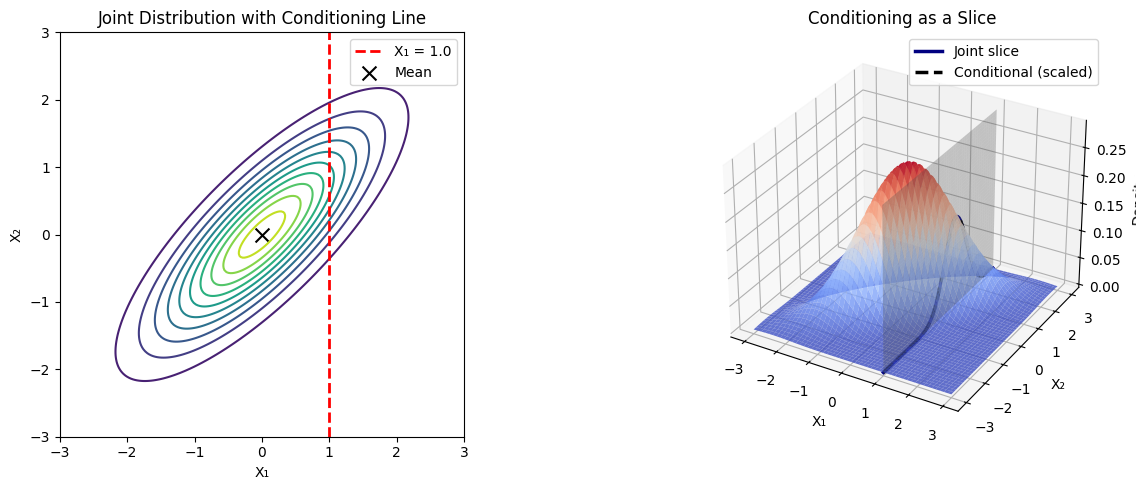

Conditional distribution: X₂ | X₁=1.0 ~ N(0.800, 0.360)


In [16]:
def plot_conditioning(mean, cov, x1_cut, num_points=200):
    """
    Visualize conditioning as a slice through the joint density.

    Parameters:
    - mean: [μ1, μ2]
    - cov: 2x2 covariance matrix
    - x1_cut: value of X1 to condition on
    """
    # Create grid
    x1 = np.linspace(mean[0] - 3*np.sqrt(cov[0,0]),
                      mean[0] + 3*np.sqrt(cov[0,0]), num_points)
    x2 = np.linspace(mean[1] - 3*np.sqrt(cov[1,1]),
                      mean[1] + 3*np.sqrt(cov[1,1]), num_points)
    X1, X2 = np.meshgrid(x1, x2)

    # Evaluate joint density
    pos = np.dstack((X1, X2))
    rv = multivariate_normal(mean, cov)
    p = rv.pdf(pos)

    # Conditional distribution parameters
    Sigma11 = cov[0, 0]
    Sigma12 = cov[0, 1]
    Sigma21 = cov[1, 0]
    Sigma22 = cov[1, 1]

    mu_cond = mean[1] + Sigma21 / Sigma11 * (x1_cut - mean[0])
    sigma_cond = np.sqrt(Sigma22 - Sigma21 * Sigma12 / Sigma11)

    # Joint density slice at x1_cut
    x2_line = x2
    joint_slice = rv.pdf(np.column_stack([x1_cut * np.ones_like(x2_line), x2_line]))

    # Conditional density (renormalized)
    rv_cond = norm(mu_cond, sigma_cond)
    cond_pdf = rv_cond.pdf(x2_line)
    cond_pdf_scaled = cond_pdf * joint_slice.max() / cond_pdf.max()

    # Plot
    fig = plt.figure(figsize=(14, 5))

    # Contour plot
    ax1 = fig.add_subplot(121)
    ax1.contour(X1, X2, p, levels=10, cmap='viridis')
    ax1.axvline(x1_cut, color='red', linestyle='--', linewidth=2, label=f'X₁ = {x1_cut}')
    ax1.scatter([mean[0]], [mean[1]], color='black', s=100, marker='x', label='Mean')
    ax1.set_xlabel('X₁')
    ax1.set_ylabel('X₂')
    ax1.set_title('Joint Distribution with Conditioning Line')
    ax1.legend()
    ax1.set_aspect('equal')

    # 3D plot
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X1, X2, p, cmap=cm.coolwarm, alpha=0.8, linewidth=0)

    # Slice plane
    wall_z = np.linspace(0, max(p.max(), cond_pdf_scaled.max()) * 1.1, num_points)
    X2_wall, Z_wall = np.meshgrid(x2_line, wall_z)
    X1_wall = x1_cut * np.ones_like(X2_wall)
    ax2.plot_surface(X1_wall, X2_wall, Z_wall, color='silver', alpha=0.3, linewidth=0)

    # Joint slice on the wall
    ax2.plot(x1_cut * np.ones_like(x2_line), x2_line, joint_slice,
             color='navy', linewidth=2.5, label='Joint slice')

    # Conditional density (scaled for display)
    ax2.plot(x1_cut * np.ones_like(x2_line), x2_line, cond_pdf_scaled,
             color='black', linewidth=2.5, linestyle='--', label='Conditional (scaled)')

    ax2.set_xlabel('X₁')
    ax2.set_ylabel('X₂')
    ax2.set_zlabel('Density')
    ax2.set_title('Conditioning as a Slice')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Conditional distribution: X₂ | X₁={x1_cut} ~ N({mu_cond:.3f}, {sigma_cond**2:.3f})")

# Visualize
mean = [0, 0]
cov = np.array([[1, 0.8], [0.8, 1]])
plot_conditioning(mean, cov, x1_cut=1.0)

**Task:** Run the visualization with different values of `x1_cut` and different correlations.

Try:
- `x1_cut = 0` (at the mean)
- `x1_cut = 2` (far from the mean)
- Change correlation to 0.2, 0.5, 0.95

**Observations:**

What happens to the slice shape as correlation changes?

What happens when you condition far from the mean?

---

## Exercise 11: Sampling from the Conditional

**Task:** Verify the conditional distribution by sampling.

1. Sample many points from the joint distribution
2. Keep only samples where $X_1 \approx x_1^*$ (within a small window)
3. Look at the histogram of the corresponding $X_2$ values
4. Compare to the theoretical conditional distribution

Number of samples near X1 = 1.0: 1186


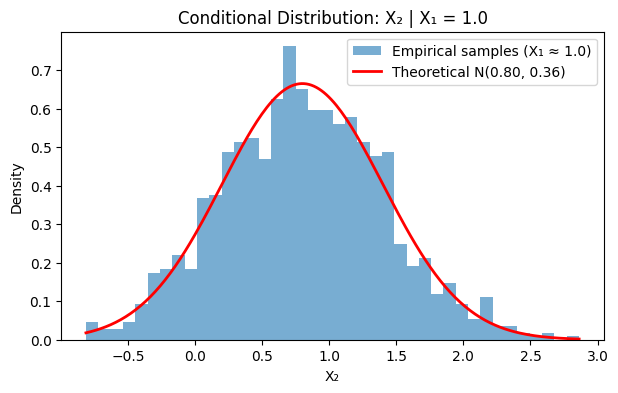


Empirical mean: 0.807
Theoretical mean: 0.800

Empirical std: 0.606
Theoretical std: 0.600


In [17]:
# Joint distribution
mean = np.array([0, 0])
cov = np.array([[1, 0.8], [0.8, 1]])

# Sample from joint
n_samples = 50000
samples = np.random.multivariate_normal(mean, cov, size=n_samples)

# Condition on X1 ≈ 1.0 (keep samples in window [0.95, 1.05])
x1_target = 1.0
window = 0.05
mask = (samples[:, 0] >= x1_target - window) & (samples[:, 0] <= x1_target + window)
conditional_samples = samples[mask, 1]

print(f"Number of samples near X1 = {x1_target}: {len(conditional_samples)}")

# Theoretical conditional
Sigma11 = cov[0, 0]
Sigma12 = cov[0, 1]
Sigma21 = cov[1, 0]
Sigma22 = cov[1, 1]

mu_cond = mean[1] + Sigma21 / Sigma11 * (x1_target - mean[0])
sigma_cond = np.sqrt(Sigma22 - Sigma21 * Sigma12 / Sigma11)

# Plot
plt.figure(figsize=(7, 4))
plt.hist(conditional_samples, bins=40, density=True, alpha=0.6,
         label=f'Empirical samples (X₁ ≈ {x1_target})')

x2_range = np.linspace(conditional_samples.min(), conditional_samples.max(), 200)
plt.plot(x2_range, norm.pdf(x2_range, mu_cond, sigma_cond),
         'r-', linewidth=2, label=f'Theoretical N({mu_cond:.2f}, {sigma_cond**2:.2f})')

plt.xlabel('X₂')
plt.ylabel('Density')
plt.title(f'Conditional Distribution: X₂ | X₁ = {x1_target}')
plt.legend()
plt.show()

print(f"\nEmpirical mean: {conditional_samples.mean():.3f}")
print(f"Theoretical mean: {mu_cond:.3f}")
print(f"\nEmpirical std: {conditional_samples.std():.3f}")
print(f"Theoretical std: {sigma_cond:.3f}")

**Explain:** Do the empirical and theoretical distributions match? What does this verify?

**Your explanation:**

---

# Summary

You now have the core tools for Gaussian Process regression:

1. **Matrix operations with Gaussians**: $Y = \mathbf{w}^T \mathbf{X} \sim \mathcal{N}(\mathbf{w}^T \boldsymbol{\mu}, \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w})$

2. **Closure properties**: Linear combinations of Gaussians are Gaussian

3. **Conditioning formulas**:
   - $\mu_{2|1} = \mu_2 + \Sigma_{21} \Sigma_{11}^{-1} (x_1 - \mu_1)$
   - $\Sigma_{2|1} = \Sigma_{22} - \Sigma_{21} \Sigma_{11}^{-1} \Sigma_{12}$

4. **Geometric intuition**: Conditioning is slicing the joint density

**Next:** Gaussian Processes — where these operations predict function values at new locations given observations at other locations.